V_max = 1.5909527379378972
Planet orbital period = 6496.166394129372


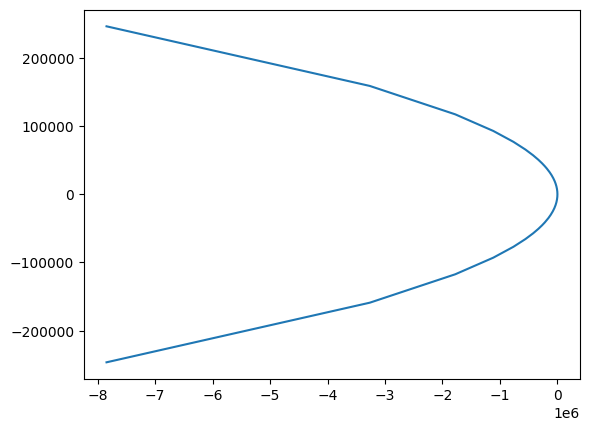

In [1]:
## Imports

import numpy as np

import matplotlib.pyplot as plt

from dataclasses import dataclass

@dataclass
class Body:
    mu: float
    r: float

bodies = {
    "earth":   Body(mu=398600,       r=6378),
    "sun":     Body(mu=132712440000, r=696000),
    "moon":    Body(mu=4902.8,       r=1737),
    "mercury": Body(mu=22032,        r=2440),
    "venus":   Body(mu=324860,       r=6052),
    "mars":    Body(mu=42828,        r=3390),
    "jupiter": Body(mu=126713000,    r=69911),
    "saturn":  Body(mu=37941000,     r=58232),
    "uranus":  Body(mu=5794500,      r=25362),
    "neptune": Body(mu=6836500,      r=24622),
    "pluto":   Body(mu=981.6,        r=1188),
}



def orbital_period(planet):
    b = bodies[planet]
    return 2 * 3.14159 * (b.r**3 / b.mu)**0.5

def calc_orbit(planet,e,r_p):
    b = bodies[planet]
    r_p = r_p+b.r
    p = r_p*(1+e)

    if e < 1:
        theta_star = np.linspace(0, 2*np.pi, 361)
    elif e == 1:
        theta_star = np.linspace(-np.pi*0.99, np.pi*0.99, 361)
    elif e > 1:
        theta_max = np.arccos(-1/e)
        theta_star = np.linspace(-theta_max*0.99, theta_max*0.99, 361)

    r = p/(1+e*np.cos(theta_star))
    x = r*np.cos(theta_star)
    y = r*np.sin(theta_star)

    v_max = np.sqrt(b.mu*((2/r_p)-(1/r_p)))

    return x,y,v_max

usr_planet=input("Planet (lowercase):")
usr_e = float(input("Enter Eccentricity (e<3 and e>=0):"))
usr_r_p = float(input("Radius of periapsis (do not include planet r, in Km):"))

x,y,v = calc_orbit(usr_planet ,usr_e ,usr_r_p)
p = orbital_period(usr_planet)
print(f"V_max = {v}")
print(f"Planet orbital period = {p}")
fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()


